# 📊 Análise Exploratória do Dataset de Triagem Médica

Este notebook documenta a análise exploratória (EDA) do dataset utilizado para treinar o classificador de urgência médica.

**Objetivo:** Entender a distribuição dos dados, qualidade dos textos e características relevantes antes do treinamento.

**Dataset:** `dataset_balanceado.csv` — 1200 exemplos balanceados (400 por classe)

**Classes:**
- 🔴 `EMERGENCIA` — Risco imediato de vida
- 🟡 `URGENTE` — Atenção em até 24h
- 🟢 `NAO_URGENTE` — Consulta agendada

## 1. Imports e Configurações

Carregamos as bibliotecas necessárias para análise e visualização.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


## 2. Carregamento do Dataset

Carregamos o dataset balanceado gerado pelo script `gerar_sinteticos.py`.

In [8]:
df = pd.read_csv('../data/processed/dataset_balanceado.csv', sep=';')

print(f'Total de exemplos: {len(df)}')
print(f'Colunas: {list(df.columns)}')
print(f'\nPrimeiras linhas:')
df.head(10)

Total de exemplos: 1200
Colunas: ['texto', 'label', 'label_num']

Primeiras linhas:


,texto,label,label_num
0,"dor no ombro, dor persistente no braço, dor na...",NAO_URGENTE,0
1,"dor no peito recorrente, dificuldade para mant...",URGENTE,1
2,"febre vaginal, sangramento vaginal",EMERGENCIA,2
3,"coceira intensa, irritação da pele",URGENTE,1
4,"respiração de falta de ar, perda de peso indes...",EMERGENCIA,2
5,"dor no tornozelo, dor no pé, dificuldade em an...",NAO_URGENTE,0
6,"dor abdominal, coceira na pele, erupção cutâne...",EMERGENCIA,2
7,"dor de cabeça leve, coceira em membros superio...",NAO_URGENTE,0
8,urina de sangue,URGENTE,1
9,"dor nasal persistente, congestão nasal",URGENTE,1


## 3. Verificação de Qualidade

Checamos valores nulos, duplicatas e consistência entre `label` e `label_num`.

In [9]:
print('=== VALORES NULOS ===')
print(df.isnull().sum())

print(f'\n=== DUPLICATAS ===')
dups = df['texto'].duplicated().sum()
print(f'Textos duplicados: {dups}')

print(f'\n=== CONSISTÊNCIA label x label_num ===')
print(df.groupby('label')['label_num'].unique())

=== VALORES NULOS ===
texto        0
label        0
label_num    0
dtype: int64

=== DUPLICATAS ===
Textos duplicados: 0

=== CONSISTÊNCIA label x label_num ===
label
EMERGENCIA     [2]
NAO_URGENTE    [0]
URGENTE        [1]
Name: label_num, dtype: object


## 4. Distribuição das Classes

Verificamos se o balanceamento foi aplicado corretamente.
Um dataset balanceado é fundamental para evitar que o modelo aprenda a chutar sempre a classe majoritária.

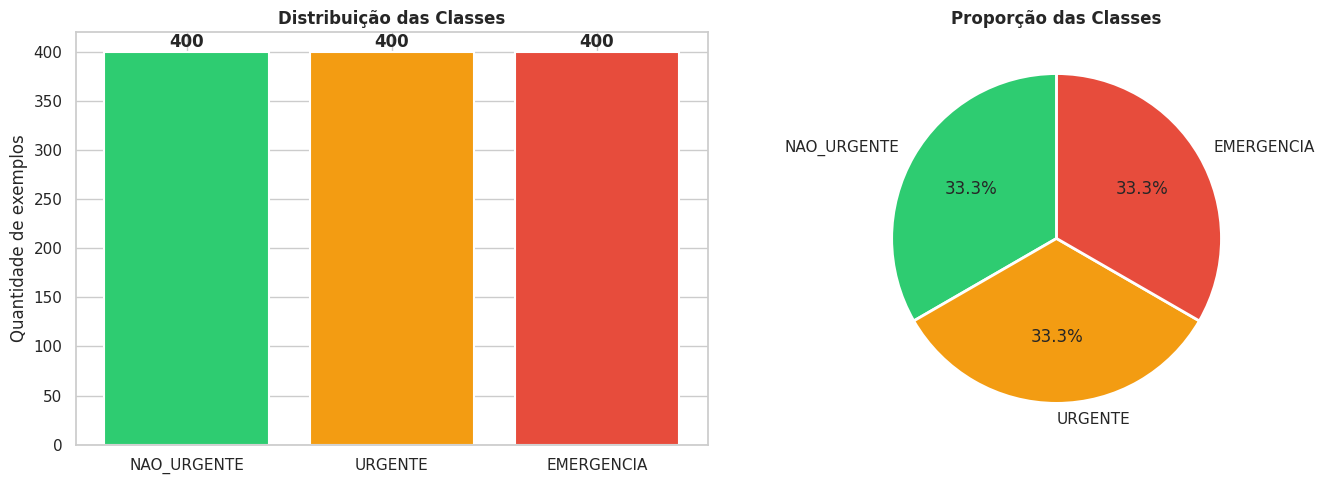

label
NAO_URGENTE    400
URGENTE        400
EMERGENCIA     400
Name: count, dtype: int64


In [10]:
dist = df['label'].value_counts()

cores = {'EMERGENCIA': '#e74c3c', 'URGENTE': '#f39c12', 'NAO_URGENTE': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
bars = axes[0].bar(dist.index, dist.values, color=[cores[l] for l in dist.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição das Classes', fontweight='bold')
axes[0].set_ylabel('Quantidade de exemplos')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
            colors=[cores[l] for l in dist.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(dist)

## 5. Análise do Comprimento dos Textos

Analisamos quantas palavras e caracteres cada relato de sintoma possui.
Textos muito curtos podem não ter contexto suficiente para o modelo — textos muito longos podem indicar ruído.

In [11]:
df['num_palavras'] = df['texto'].apply(lambda x: len(str(x).split()))
df['num_chars']    = df['texto'].apply(lambda x: len(str(x)))
df['num_sintomas'] = df['texto'].apply(lambda x: len(str(x).split(',')))

print('=== ESTATÍSTICAS GERAIS ===')
print(df[['num_palavras', 'num_chars', 'num_sintomas']].describe().round(1))

=== ESTATÍSTICAS GERAIS ===
       num_palavras  num_chars  num_sintomas
count        1200.0     1200.0        1200.0
mean           13.4       88.3           4.5
std            10.0       67.6           3.3
min             2.0       11.0           1.0
25%             7.0       45.0           2.0
50%            10.0       66.0           3.0
75%            16.0      105.0           5.0
max            67.0      449.0          22.0


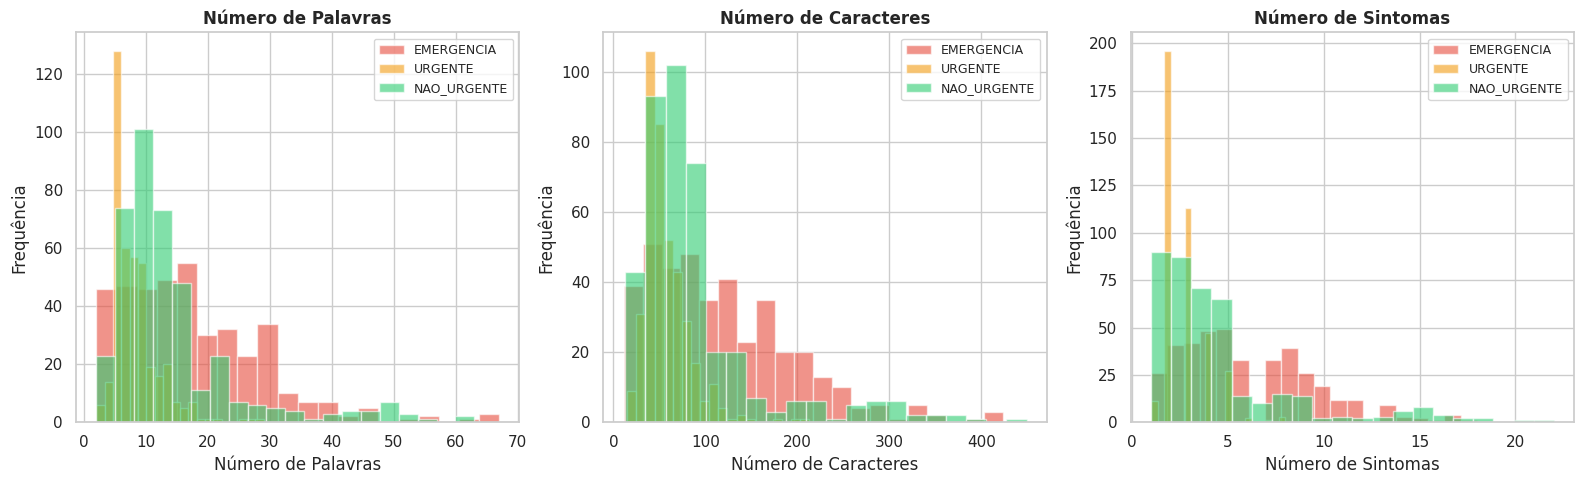

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = [
    ('num_palavras', 'Número de Palavras'),
    ('num_chars',    'Número de Caracteres'),
    ('num_sintomas', 'Número de Sintomas'),
]

for ax, (col, titulo) in zip(axes, metricas):
    for label, cor in cores.items():
        subset = df[df['label'] == label][col]
        ax.hist(subset, alpha=0.6, label=label, color=cor, bins=20, edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/distribuicao_tamanhos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Palavras Mais Frequentes por Classe

Identificamos quais sintomas aparecem mais em cada classe.
Isso ajuda a entender se o modelo terá sinais claros para aprender a distinção entre as classes.

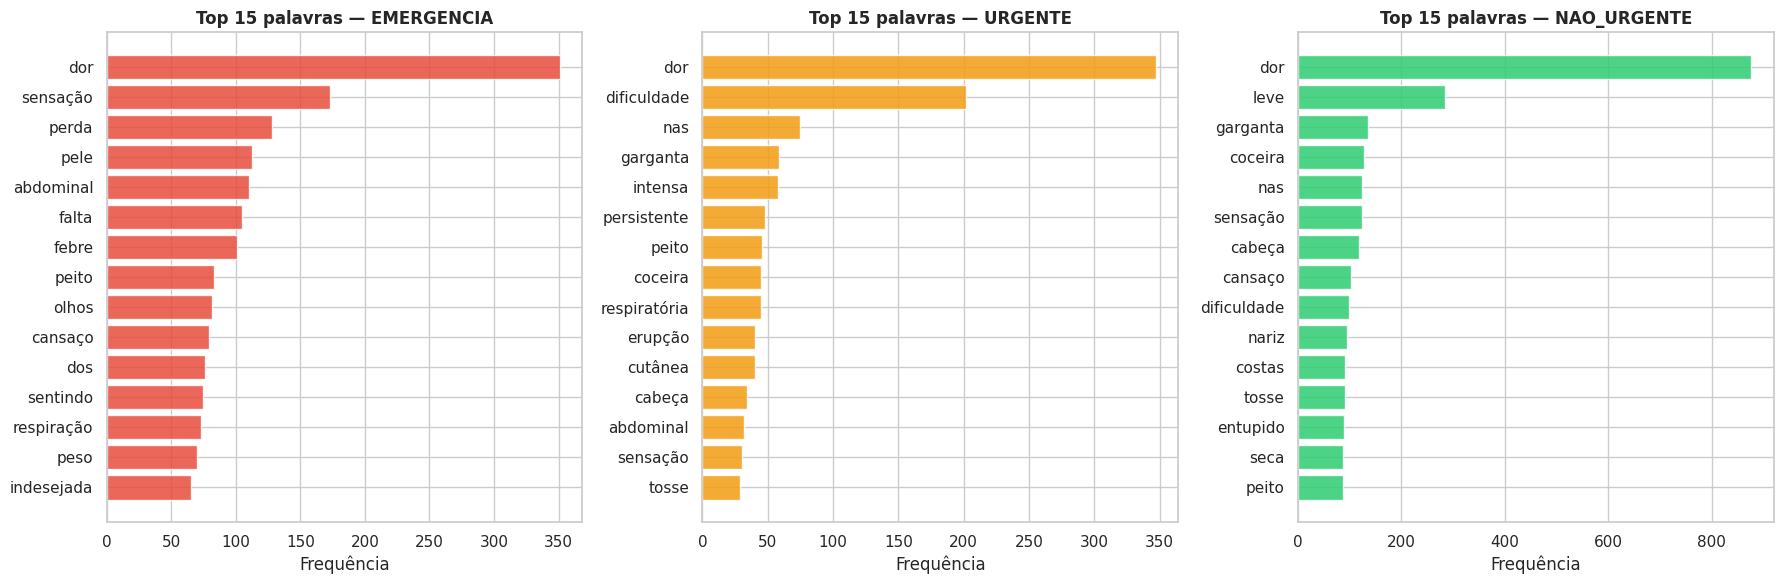

In [13]:
# Stopwords simples em português
stopwords = {'de', 'da', 'do', 'e', 'a', 'o', 'em', 'no', 'na', 'com', 'um', 'uma',
             'se', 'ao', 'os', 'as', 'que', 'por', 'para', 'ou', 'mais', 'muito'}

def top_palavras(textos, n=15):
    todas = []
    for t in textos:
        palavras = re.findall(r'\b[a-záéíóúãõâêîôûàèìòùç]{3,}\b', str(t).lower())
        todas.extend([p for p in palavras if p not in stopwords])
    return Counter(todas).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, cor) in zip(axes, cores.items()):
    textos = df[df['label'] == label]['texto']
    top = top_palavras(textos)
    palavras, contagens = zip(*top)

    bars = ax.barh(list(reversed(palavras)), list(reversed(contagens)), color=cor, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top 15 palavras — {label}', fontweight='bold')
    ax.set_xlabel('Frequência')

plt.tight_layout()
plt.savefig('../reports/top_palavras_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Exemplos por Classe

Visualizamos exemplos reais de cada classe para validar a qualidade dos dados e dos dados sintéticos gerados.

In [14]:
for label in ['EMERGENCIA', 'URGENTE', 'NAO_URGENTE']:
    print(f'\n{'='*60}')
    print(f'  {label}')
    print(f'{'='*60}')
    exemplos = df[df['label'] == label]['texto'].sample(5, random_state=42)
    for i, ex in enumerate(exemplos, 1):
        print(f'  {i}. {ex}')


  EMERGENCIA
  1. dedos rígidos
  2. respiração de falta de ar, dor no peito, sensação de fiação, perda de consciência, sensação de cansaço após a atividade
  3. febre, falta de ar, sentindo-se cansado, dor abdominal, perda de peso indesejada, perda de apetite, sentindo-se doente, vômitos, tosse, assobio ao respirar, diarreia
  4. febre, sentir-se doente, vômitos, dor abdominal superior direita, pele amarelada, amarelecimento dos brancos dos olhos, fezes coloridas de argila, coceira
  5. perda de consciência, movimentos incontroláveis, olhando, mudanças emocionais repentinas, frequência cardíaca rápida, ondas de calor frio, dentes apertando, saliva vazando da boca, movimentos oculares anormais, perda da bexiga, controle do intestino da perda, grunhidos

  URGENTE
  1. sangramento nasal persistente, dor nas costas, dificuldade respiratória
  2. dor no peito, dormência súbita, fraqueza no braço, fraqueza nas pernas, fala arrastada, dificuldade em falar, perda de visão temporária
  3. do

## 8. Conclusões da EDA

Resumo dos achados que guiarão as decisões de modelagem.

In [15]:
print('=== RESUMO DA EDA ===')
print(f'Total de exemplos:        {len(df)}')
print(f'Classes:                  {df["label"].nunique()}')
print(f'Exemplos por classe:      {dict(df["label"].value_counts())}')
print(f'Média de palavras:        {df["num_palavras"].mean():.1f}')
print(f'Média de sintomas:        {df["num_sintomas"].mean():.1f}')
print(f'Textos duplicados:        {df["texto"].duplicated().sum()}')
print(f'Valores nulos:            {df.isnull().sum().sum()}')
print(f'\n✅ Dataset pronto para treinamento!')

=== RESUMO DA EDA ===
Total de exemplos:        1200
Classes:                  3
Exemplos por classe:      {'NAO_URGENTE': np.int64(400), 'URGENTE': np.int64(400), 'EMERGENCIA': np.int64(400)}
Média de palavras:        13.4
Média de sintomas:        4.5
Textos duplicados:        0
Valores nulos:            0

✅ Dataset pronto para treinamento!
